# ep01: カカオ価格高騰は何か月遅れてチョコの値段に届いたか

- 動画: （公開後にリンクを追記）
- note記事: https://note.com/joyous_poppy3578/n/ndbd1ef21754c

## 0. 概要

**何を調べたか**: 2024年に歴史的な暴騰を記録したカカオの国際価格が、日本のチョコレート小売価格
（消費者物価指数のチョコレート品目指数）に、どれくらいの時間差（ラグ）で・どの程度反映されたかを、
月次データの相互相関分析（CCF）で調べた。

**何が分かったか**: 円建てのカカオ価格からチョコレートCPIへの転嫁ラグは、**おおよそ7か月前後**。
素のCCF（何も補正しない相互相関）と、系列のクセ（自己相関）を取り除いた「プリホワイトニング」後の
CCFの両方でピークの位置がほぼ一致しており、結果は頑健だと判断できる（詳細は3-3節）。

**何が分からなかったか**: 全期間では頑健だった「約7か月」というラグは、2024年の暴騰前後で
局面を分けて推定し直すと再現されない（チョコCPI・相対チョコCPIのどちらも）。局面によって本当に
転嫁のスピードが変わったのか、単に局面ごとのサンプル数が少なくて推定が不安定なだけなのかを、
このデータだけでは切り分けられなかった（詳細は3-4節）。

このノートブックは、社内の作業用ノートブック（Phase1〜3）で行った分析を、**読者が上から順に読んで
理解できる「物語」として書き直したもの**。試行錯誤の過程で「却下した手法」「判定が割れた箇所」
「想定と食い違った結果」もあえて明示的に残している。

## 1. データの取得

使用データと出典（すべて月次、2015年1月〜）:

| # | データ | 出典 | 役割 |
|---|---|---|---|
| 1 | カカオ国際価格（USD/kg） | 世界銀行 Pink Sheet（Commodity Markets, "Monthly Prices"シート） | 説明変数（USD建て） |
| 2 | CPI「チョコレート」品目指数 | 総務省 消費者物価指数（2020年基準）／ e-Stat統計表ID 0003427113 | 被説明変数（主） |
| 3 | 総合CPI | 同上（品目コード0001） | 相対価格の分母 |
| 4 | カカオ豆輸入単価（円/kg） | 財務省 貿易統計 HS1801（e-Stat, 品別国別表） | 説明変数（円建て・実勢コスト） |
| 5 | USD/JPY為替レート | ECB（欧州中央銀行）参照レート（frankfurter.app 経由） | 恒等分解の部品（今回は未使用、§1末尾を参照） |
| 6 | 小売物価統計「チョコレート」（東京都区部） | 総務省 小売物価統計調査／ e-Stat統計表ID 0003421913 | **取得のみ・未使用**（後述） |
| 7 | 砂糖の国際価格 | 世界銀行 Pink Sheet（同一ファイル, "Sugar, world"列） | **取得のみ・未使用**（後述） |

取得日は各セルの実行時点。データファイルそのものはこのリポジトリには含めていない
（`.gitignore` で `data/` を除外する想定）。以下のセルを上から実行すれば、その場でダウンロードされる。

**e-Stat APIキーについて**: 総務省統計局のCPI・小売物価統計は e-Stat API（要アプリケーションID）から
取得する。APIキーはコードに直書きせず、環境変数 `ESTAT_APP_ID` から読む
（`os.environ.get("ESTAT_APP_ID")`）。このリポジトリを自分の環境で動かす場合は、
[e-Stat](https://www.e-stat.go.jp/) でユーザー登録・アプリケーション登録を行い、
自分の環境変数に `ESTAT_APP_ID` を設定してから実行すること。

### セットアップ

このノートブックが置かれているディレクトリを基準に、データ・図の保存先を決める
（プロジェクトルートへの絶対パス参照はしない。単体で完結させるため）。

In [1]:
# --- セットアップ ---
import sys
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

# 日本語フォント（Windows: Meiryo を font manager で明示指定）
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False  # マイナス記号の豆腐化を防ぐ

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# このノートブック単体で完結させるため、実行ディレクトリ（notebookのある場所）を
# データ・図の保存先の基準にする（絶対パスはハードコードしない）
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "figures"
for d in (RAW_DIR, PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

_HEADERS = {"User-Agent": "Mozilla/5.0 (ep01_cacao notebook)"}

# e-Stat appID はOSの環境変数から直接読む（.envファイルの自動探索は行わない。
# 上位ディレクトリを辿る探索は、意図しない.envを拾うリスクがあるため採用しない）
ESTAT_APP_ID = os.environ.get("ESTAT_APP_ID")
if ESTAT_APP_ID:
    print("ESTAT_APP_ID: 環境変数から読み込みました（値は表示しません）")
else:
    raise RuntimeError(
        "環境変数 ESTAT_APP_ID が未設定です。\n"
        "PowerShellの場合、実行前に以下を設定してください:\n"
        "  $env:ESTAT_APP_ID = 'あなたのappID'\n"
        "永続化する場合（新しいターミナルでも有効にする）:\n"
        "  setx ESTAT_APP_ID \"あなたのappID\""
    )

print("セットアップ完了 / 保存先ディレクトリ名:", RAW_DIR.name, PROCESSED_DIR.name, FIG_DIR.name)

ESTAT_APP_ID: 環境変数から読み込みました（値は表示しません）
セットアップ完了 / 保存先ディレクトリ名: raw processed figures


### 1-1. カカオ・砂糖の国際価格（世界銀行 Pink Sheet）

Pink Sheet の配布Excelは、URLの版番号が毎月変わる。固定URLをハードコードすると数か月で
リンク切れになるため、Commodity Markets のページHTMLから最新リンクを正規表現で動的に取得する。

In [2]:
_PINKSHEET_PAGE = "https://www.worldbank.org/en/research/commodity-markets"
_PINKSHEET_FILE = RAW_DIR / "CMO-Historical-Data-Monthly.xlsx"


def _discover_pinksheet_url() -> str:
    '''Commodity Markets ページのHTMLから、月次Excelへの最新リンクを1つ取り出す。'''
    r = requests.get(_PINKSHEET_PAGE, headers=_HEADERS, timeout=60)
    r.raise_for_status()
    matches = re.findall(r"https://[^\s\"'<>]*CMO-Historical-Data-Monthly\.xlsx", r.text)
    if not matches:
        raise RuntimeError("Commodity Marketsページからリンクを検出できませんでした（ページ構造変更の可能性）。")
    return matches[0]


def _download_pinksheet(force: bool = False) -> Path:
    '''Pink SheetのExcelをdata/raw/にダウンロード（キャッシュ優先）。'''
    if _PINKSHEET_FILE.exists() and not force:
        return _PINKSHEET_FILE
    url = _discover_pinksheet_url()
    r = requests.get(url, headers=_HEADERS, timeout=180)
    r.raise_for_status()
    _PINKSHEET_FILE.write_bytes(r.content)
    return _PINKSHEET_FILE


def load_pinksheet_column(colname: str, out_name: str, force: bool = False) -> pd.DataFrame:
    '''Pink Sheetの「Monthly Prices」シートから商品名(colname)の列を月次で取り出す。

    列位置は版によってズレるため、固定インデックスではなく行4の商品名で列を特定する。
    '''
    path = _download_pinksheet(force=force)
    raw = pd.read_excel(path, sheet_name="Monthly Prices", header=None, engine="openpyxl")
    name_row = raw.iloc[4].astype(str)
    matches = name_row[name_row == colname].index
    if len(matches) == 0:
        raise RuntimeError(f"Pink Sheetに列 '{colname}' が見つかりません（版変更の可能性）。")
    col = matches[0]
    unit = str(raw.iloc[5, col])
    df = raw.loc[6:, [0, col]].copy()
    df.columns = ["date_str", out_name]
    df["date"] = pd.to_datetime(df["date_str"].str.replace("M", "-", regex=False), format="%Y-%m")
    df[out_name] = pd.to_numeric(df[out_name], errors="coerce")  # '…'など非数値はNaN化
    df = df.set_index("date")[[out_name]].sort_index()
    df.attrs["unit"] = unit
    return df


cocoa = load_pinksheet_column("Cocoa", "cocoa_usd_per_kg")
sugar = load_pinksheet_column("Sugar, world", "sugar_usd_per_kg")

print(f"カカオ国際価格: 単位={cocoa.attrs['unit']} 期間={cocoa.index.min().date()}〜{cocoa.index.max().date()} "
      f"欠損={cocoa['cocoa_usd_per_kg'].isna().sum()}")
print(f"砂糖国際価格  : 単位={sugar.attrs['unit']} 期間={sugar.index.min().date()}〜{sugar.index.max().date()} "
      f"欠損={sugar['sugar_usd_per_kg'].isna().sum()}")
cocoa.tail(3)

カカオ国際価格: 単位=($/kg) 期間=1960-01-01〜2026-07-01 欠損=0
砂糖国際価格  : 単位=($/kg) 期間=1960-01-01〜2026-07-01 欠損=0


,cocoa_usd_per_kg
date,
2026-05-01,4.16
2026-06-01,4.40
2026-07-01,5.61


### 1-2. CPI（消費者物価指数）チョコレート品目・総合

総務省の消費者物価指数（2020年基準）を e-Stat API から取得する。統計表ID `0003427113`。
品目コード `1761`=チョコレート、`0001`=総合、地域コード `00000`=全国。

In [3]:
_ESTAT_BASE = "https://api.e-stat.go.jp/rest/3.0/app/json"


def estat_getstatsdata(statsdata_id: str, params: dict, cache_name: str, force: bool = False) -> list:
    '''e-Stat getStatsData を呼び、VALUE（データ本体）のリストを返す。data/raw/にキャッシュする。'''
    cache_path = RAW_DIR / cache_name
    if cache_path.exists() and not force:
        payload = json.loads(cache_path.read_text(encoding="utf-8"))
    else:
        if not ESTAT_APP_ID:
            raise RuntimeError("環境変数 ESTAT_APP_ID が未設定のため e-Stat を取得できません。")
        q = {"appId": ESTAT_APP_ID, "statsDataId": statsdata_id, "limit": 100000}
        q.update(params)
        r = requests.get(f"{_ESTAT_BASE}/getStatsData", params=q, headers=_HEADERS, timeout=180)
        r.raise_for_status()
        payload = r.json()
        # appIDはURLのクエリに含まれるが、レスポンス本文自体には残らないのでそのままキャッシュしてよい
        cache_path.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    result = payload["GET_STATS_DATA"]["RESULT"]
    if str(result["STATUS"]) != "0":
        raise RuntimeError(f"e-Stat エラー: {result.get('ERROR_MSG')}")
    values = payload["GET_STATS_DATA"]["STATISTICAL_DATA"]["DATA_INF"]["VALUE"]
    return values if isinstance(values, list) else [values]


def estat_time_to_month(time_code: str):
    '''e-Statの月次コード（例 2026000505 → 2026年5月）を月初Timestampに変換。年平均はNoneを返す。'''
    year = int(time_code[:4])
    month = int(time_code[6:8])
    if month == 0:  # 年平均データは月次系列から除外
        return None
    return pd.Timestamp(year=year, month=month, day=1)


_CPI_TABLE = "0003427113"


def load_cpi_item(cat01_code: str, out_name: str, cache_name: str, force: bool = False) -> pd.DataFrame:
    values = estat_getstatsdata(_CPI_TABLE, {"cdCat01": cat01_code, "cdArea": "00000", "cdTab": "1"},
                                 cache_name, force=force)
    rows = []
    for v in values:
        month = estat_time_to_month(v["@time"])
        if month is None:
            continue
        rows.append((month, pd.to_numeric(v["$"], errors="coerce")))
    df = pd.DataFrame(rows, columns=["date", out_name]).set_index("date").sort_index()
    df.attrs["unit"] = "指数(2020年=100)"
    return df


cpi_chocolate = load_cpi_item("1761", "cpi_chocolate", "estat_cpi_chocolate.json")
cpi_overall = load_cpi_item("0001", "cpi_overall", "estat_cpi_overall.json")

print(f"CPIチョコレート品目指数: 期間={cpi_chocolate.index.min().date()}〜{cpi_chocolate.index.max().date()} "
      f"欠損={cpi_chocolate['cpi_chocolate'].isna().sum()}")
print(f"総合CPI                : 期間={cpi_overall.index.min().date()}〜{cpi_overall.index.max().date()} "
      f"欠損={cpi_overall['cpi_overall'].isna().sum()}")
cpi_chocolate.tail(3)

CPIチョコレート品目指数: 期間=1970-01-01〜2026-06-01 欠損=0
総合CPI                : 期間=1970-01-01〜2026-06-01 欠損=0


,cpi_chocolate
date,
2026-04-01,190.1
2026-05-01,192.8
2026-06-01,192.3


### 1-3. カカオ豆輸入単価（財務省 貿易統計 HS1801）

財務省貿易統計（品別国別表・輸入, HS1801=カカオ豆）を e-Stat 経由で取得し、
**輸入額(千円)÷輸入数量(kg)** で円建ての実勢輸入単価を作る。全国合計のコードが存在しないため、
輸入相手国ごとの値を合算してから単価を計算する。統計表は年区分ごとに4つに分かれているため
（対象期間が2015年〜のため、2011〜2015年の表も含めて結合し、2015-01以降だけを後で使う）、
横断的に結合する。

In [4]:
# 貿易統計は年区分ごとにテーブルが分かれている（品別国別表・輸入）
_TRADE_TABLES = ["0003228185", "0003313966", "0003425294", "0004049326"]
_HS1801 = "180100000"
# 月 m の (金額cat02コード, 数量2cat02コード)。統計表の仕様: 1月_金額=170, 30ずつ増加
_TRADE_MONTH_CODES = {m: (str(170 + 30 * (m - 1)), str(160 + 30 * (m - 1))) for m in range(1, 13)}


def load_trade_one_table(table_id: str, force: bool = False) -> pd.DataFrame:
    '''1つの貿易統計テーブルからHS1801の月次(金額千円・数量kg)を国合算して返す。'''
    values = estat_getstatsdata(table_id, {"cdCat01": _HS1801}, f"estat_trade_1801_{table_id}.json", force=force)
    amt_codes = {c[0] for c in _TRADE_MONTH_CODES.values()}
    qty_codes = {c[1] for c in _TRADE_MONTH_CODES.values()}
    amt_sum, qty_sum = {}, {}
    for v in values:
        c2 = v["@cat02"]
        if c2 not in amt_codes and c2 not in qty_codes:
            continue
        year = int(v["@time"][:4])
        val = pd.to_numeric(v["$"], errors="coerce")
        if pd.isna(val):
            continue
        bucket = amt_sum if c2 in amt_codes else qty_sum
        bucket[(year, c2)] = bucket.get((year, c2), 0.0) + val  # 相手国を合算

    rows = []
    years = {k[0] for k in amt_sum} | {k[0] for k in qty_sum}
    for year in sorted(years):
        for m, (amt_c, qty_c) in _TRADE_MONTH_CODES.items():
            amt, qty = amt_sum.get((year, amt_c)), qty_sum.get((year, qty_c))
            if amt is None or qty is None or qty == 0:
                continue  # 未公表月はスキップ
            rows.append((pd.Timestamp(year=year, month=m, day=1), amt * 1000.0 / qty))  # 円/kg
    return pd.DataFrame(rows, columns=["date", "cacao_import_jpy_per_kg"])


parts = [load_trade_one_table(t) for t in _TRADE_TABLES]
cacao_import = pd.concat(parts, ignore_index=True).drop_duplicates(subset="date", keep="last")
cacao_import = cacao_import.set_index("date").sort_index()

print(f"カカオ豆輸入単価: 期間={cacao_import.index.min().date()}〜{cacao_import.index.max().date()} "
      f"欠損={cacao_import['cacao_import_jpy_per_kg'].isna().sum()}")
cacao_import.tail(3)

カカオ豆輸入単価: 期間=2011-01-01〜2026-06-01 欠損=0


,cacao_import_jpy_per_kg
date,
2026-04-01,1410.847192
2026-05-01,1519.548640
2026-06-01,1457.888471


### 1-4. USD/JPY為替レート

**却下した手法（重要）**: 為替の取得元は当初FRED（セントルイス連銀）を想定していた。しかし
FREDはAPIキー・地域によるアクセス制限の影響を受けやすく、「実行環境によって取得できたりできなかったり」
すると、このノートブックの再現性が損なわれる。そこで**キー不要・世界中どこからでも安定して取得できる
ECB（欧州中央銀行）参照レート**（frankfurter.app 経由）に切り替えた。日次の参照レートを月次平均に
集約する。この判断により、恒等分解（`Δlog(円建てカカオ) = Δlog(USD建てカカオ) + Δlog(為替)`）の
構成部品として使う為替系列が、環境によって変わらない単一ソースに固定される
（ただし今回のノートブックでは恒等分解自体は実施していない。§4「結論と限界」参照）。

In [5]:
_ECB_URL = "https://api.frankfurter.app/{start}..{end}?from=USD&to=JPY"


def load_usdjpy(force: bool = False) -> pd.DataFrame:
    '''USD/JPY（円/USD, 月次平均）。ECB参照レートの日次値を月次平均に集約する。'''
    cache = RAW_DIR / "usdjpy_ecb.json"
    if cache.exists() and not force:
        payload = json.loads(cache.read_text(encoding="utf-8"))
    else:
        today = pd.Timestamp.today().strftime("%Y-%m-%d")
        url = _ECB_URL.format(start="2015-01-01", end=today)
        r = requests.get(url, headers=_HEADERS, timeout=60)
        r.raise_for_status()
        payload = r.json()
        cache.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    s = pd.Series({d: v["JPY"] for d, v in payload["rates"].items()})
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    monthly = s.resample("MS").mean()  # 日次 → 月次平均
    df = monthly.to_frame("usdjpy")
    df.index.name = "date"
    df.attrs["unit"] = "円/USD（月次平均）"
    return df


usdjpy = load_usdjpy()
print(f"USD/JPY(ECB月次平均): 期間={usdjpy.index.min().date()}〜{usdjpy.index.max().date()} "
      f"欠損={usdjpy['usdjpy'].isna().sum()}")
usdjpy.tail(3)

USD/JPY(ECB月次平均): 期間=2014-12-01〜2026-08-01 欠損=0


,usdjpy
date,
2026-06-01,160.725000
2026-07-01,162.505652
2026-08-01,158.097500


### 1-5. 小売物価統計「チョコレート」（取得するが未使用）

総務省 小売物価統計調査（e-Stat統計表ID `0003421913`, 品目コード`1761`, 地域コード`13100`=東京都区部）
から、チョコレートの実売価格（円）を取得する。

**この系列は今回の分析（本命4ペアのCCF）には使用していない**。理由は、被説明変数を
CPIチョコレート品目指数に確定したため（銘柄改定リスクを回避できる）。参考情報として取得のみ行う。

In [6]:
_RETAIL_TABLE = "0003421913"

retail_values = estat_getstatsdata(
    _RETAIL_TABLE, {"cdCat02": "01761", "cdArea": "13100", "cdTab": "10"},
    "estat_retail_chocolate.json",
)
rows = []
for v in retail_values:
    month = estat_time_to_month(v["@time"])
    if month is None:
        continue
    rows.append((month, pd.to_numeric(v["$"], errors="coerce")))
retail_chocolate = pd.DataFrame(rows, columns=["date", "retail_chocolate_tokyo_yen"]).set_index("date").sort_index()

print(f"小売物価統計チョコ(東京都区部, 未使用): 期間={retail_chocolate.index.min().date()}〜"
      f"{retail_chocolate.index.max().date()} 欠損={retail_chocolate['retail_chocolate_tokyo_yen'].isna().sum()}")
retail_chocolate.tail(3)

小売物価統計チョコ(東京都区部, 未使用): 期間=2000-01-01〜2026-06-01 欠損=0


,retail_chocolate_tokyo_yen
date,
2026-04-01,397
2026-05-01,412
2026-06-01,404


### 1-6. 全系列の結合

7系列を月次の日付インデックスで外部結合し、`data/processed/monthly_master.csv` に保存する。
2015-01以降に絞る。

**再掲: 未使用系列の明記** — `sugar_usd_per_kg`（砂糖国際価格）と `retail_chocolate_tokyo_yen`
（小売物価統計チョコ）は取得しているが、本ノートブックの本命分析（3節のCCF・局面比較）では
**使用しない**。取得のみ行った参考情報として `master` に含めている。

In [7]:
master = pd.concat([cocoa, sugar, cpi_chocolate, cpi_overall, retail_chocolate, usdjpy, cacao_import], axis=1)
master = master.sort_index()
master = master[master.index >= pd.Timestamp("2015-01-01")]
master.index.name = "date"

print("結合マスター shape:", master.shape)
print("列:", list(master.columns))
print("期間:", master.index.min().date(), "〜", master.index.max().date())
print("\n系列ごとの欠損数:")
print(master.isna().sum())

master.to_csv(PROCESSED_DIR / "monthly_master.csv", encoding="utf-8-sig")
master.tail(3)

結合マスター shape: (140, 7)
列: ['cocoa_usd_per_kg', 'sugar_usd_per_kg', 'cpi_chocolate', 'cpi_overall', 'retail_chocolate_tokyo_yen', 'usdjpy', 'cacao_import_jpy_per_kg']
期間: 2015-01-01 〜 2026-08-01

系列ごとの欠損数:
cocoa_usd_per_kg              1
sugar_usd_per_kg              1
cpi_chocolate                 2
cpi_overall                   2
retail_chocolate_tokyo_yen    2
usdjpy                        0
cacao_import_jpy_per_kg       2
dtype: int64


,cocoa_usd_per_kg,sugar_usd_per_kg,cpi_chocolate,cpi_overall,retail_chocolate_tokyo_yen,usdjpy,cacao_import_jpy_per_kg
date,,,,,,,
2026-06-01,4.40,0.32,192.3,113.6,404.0,160.725000,1457.888471
2026-07-01,5.61,0.34,NaN,NaN,NaN,162.505652,NaN
2026-08-01,NaN,NaN,NaN,NaN,NaN,158.097500,NaN


## 2. 前処理

### 2-1. 未完了月の除外

月次系列のうち、**実行日が属する月**（まだ月末を迎えていない月）は、月次平均がその月の途中まで
の値でしか計算されていない。特に為替 `usdjpy` は「日次の月内平均」なので、同じ月でも実行日が違えば
値が変わってしまう。分析の再現性を壊すので、当月の行は落とす。

In [8]:
def drop_incomplete_month(df: pd.DataFrame) -> pd.DataFrame:
    '''実行日が属する月（月次平均が未確定な当月）の行を落として返す。'''
    today = pd.Timestamp.today()
    current_month_start = pd.Timestamp(year=today.year, month=today.month, day=1)
    return df[df.index < current_month_start].copy()


df = drop_incomplete_month(master)
print("除外前の最終月:", master.index.max().date())
print("除外後の最終月:", df.index.max().date(), "（当月の行を除外した）")
df.tail(4)

除外前の最終月: 2026-08-01
除外後の最終月: 2026-07-01 （当月の行を除外した）


,cocoa_usd_per_kg,sugar_usd_per_kg,cpi_chocolate,cpi_overall,retail_chocolate_tokyo_yen,usdjpy,cacao_import_jpy_per_kg
date,,,,,,,
2026-04-01,3.40,0.32,190.1,113.0,397.0,159.063500,1410.847192
2026-05-01,4.16,0.34,192.8,113.5,412.0,158.239000,1519.548640
2026-06-01,4.40,0.32,192.3,113.6,404.0,160.725000,1457.888471
2026-07-01,5.61,0.34,NaN,NaN,NaN,162.505652,NaN


### 2-2. 派生系列の作成

| 新系列 | 定義 | 目的 |
|---|---|---|
| `cocoa_jpy_per_kg` | `cocoa_usd_per_kg × usdjpy` | 円建てカカオ（スポット×為替の恒等式） |
| `rel_cpi_chocolate` | `cpi_chocolate ÷ cpi_overall × 100` | 一般物価インフレを差し引いた「チョコ固有の値上がり」 |
| `dlog_*`（6系列） | `np.log(x).diff()` | 前月比の変化率（対数1階差分） |

**なぜ対数差分を使うか**: 価格の**水準**は右肩上がりで非定常（平均が時間とともに動く）。
非定常な系列同士のCCFは「見せかけの相関」を出しやすいため、対数を取ってから前月との差を取り
（対数1階差分）、定常に近い「前月比の変化率」に変換してから分析する。

In [9]:
# 円建てカカオ = USD建てカカオ × USD/JPY為替
df["cocoa_jpy_per_kg"] = df["cocoa_usd_per_kg"] * df["usdjpy"]

# 相対価格 = チョコCPI ÷ 総合CPI × 100（一般物価インフレを分離する）
df["rel_cpi_chocolate"] = df["cpi_chocolate"] / df["cpi_overall"] * 100

# 対数1階差分を取る6系列
dlog_targets = [
    "cocoa_usd_per_kg",         # USD建てカカオ
    "cocoa_jpy_per_kg",         # 円建てカカオ
    "usdjpy",                   # 為替
    "cpi_chocolate",            # チョコCPI（名目）
    "rel_cpi_chocolate",        # 相対チョコCPI
    "cacao_import_jpy_per_kg",  # 円建て輸入単価（実勢）
]
for col in dlog_targets:
    df["dlog_" + col] = np.log(df[col]).diff()  # 対数を取ってから1期差分 = 前月比の変化率（先頭月はNaN）

dlog_cols = ["dlog_" + c for c in dlog_targets]
df[["cocoa_jpy_per_kg", "rel_cpi_chocolate"] + dlog_cols].tail(4)

,cocoa_jpy_per_kg,rel_cpi_chocolate,dlog_cocoa_usd_per_kg,dlog_cocoa_jpy_per_kg,dlog_usdjpy,dlog_cpi_chocolate,dlog_rel_cpi_chocolate,dlog_cacao_import_jpy_per_kg
date,,,,,,,,
2026-04-01,540.815900,168.230088,0.048202,0.050645,0.002443,-0.003151,-0.005810,-0.044755
2026-05-01,658.274240,169.867841,0.201740,0.196543,-0.005197,0.014103,0.009688,0.074223
2026-06-01,707.190000,169.278169,0.056089,0.071678,0.015588,-0.002597,-0.003477,-0.041424
2026-07-01,911.656709,NaN,0.242946,0.253964,0.011018,NaN,NaN,NaN


### 2-3. データのざっと確認（可視化）

分析に入る前に、原系列の動きを4枚のグラフでざっと確認する。

#### 図1. 指数化比較（2015-01=100）

**メッセージ**: 「原料は数倍、小売は緩やか」。円建てカカオ・輸入単価・チョコCPIを
2015-01=100に指数化して重ねると、原料が数倍に跳ねる一方、小売のチョコCPIはそれよりずっと
緩やかに上がっていることが1枚で分かる。

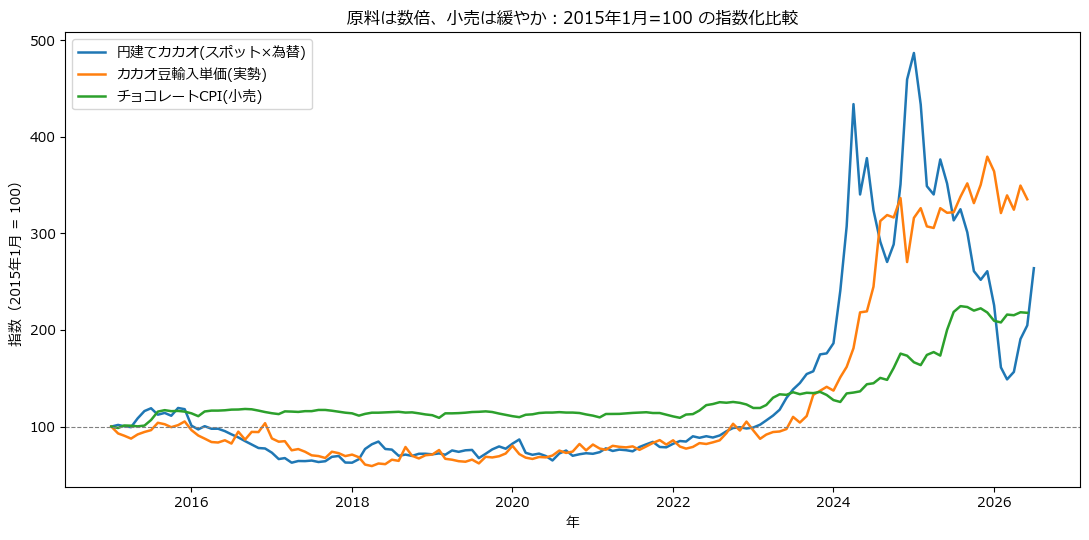

In [10]:
index_targets = {
    "cocoa_jpy_per_kg":        "円建てカカオ(スポット×為替)",
    "cacao_import_jpy_per_kg": "カカオ豆輸入単価(実勢)",
    "cpi_chocolate":           "チョコレートCPI(小売)",
}
base_date = df.index[0]  # 2015-01

fig, ax = plt.subplots(figsize=(11, 5.5))
for col, label in index_targets.items():
    base_value = df.loc[base_date, col]
    indexed = df[col] / base_value * 100  # 基準月=100に指数化
    ax.plot(df.index, indexed, label=label, linewidth=1.8)

ax.axhline(100, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("原料は数倍、小売は緩やか：2015年1月=100 の指数化比較")
ax.set_ylabel("指数（2015年1月 = 100）")
ax.set_xlabel("年")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_indexed_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

#### 図2. 二軸プロット（円建てカカオ vs チョコCPI）

原料コスト（円建てカカオ）と小売価格（チョコCPI）を重ねて見る。単位が違うので二軸にし、
**軸の色と線の色・凡例を対応させて**、どちらの線がどちらの軸かを明示する。

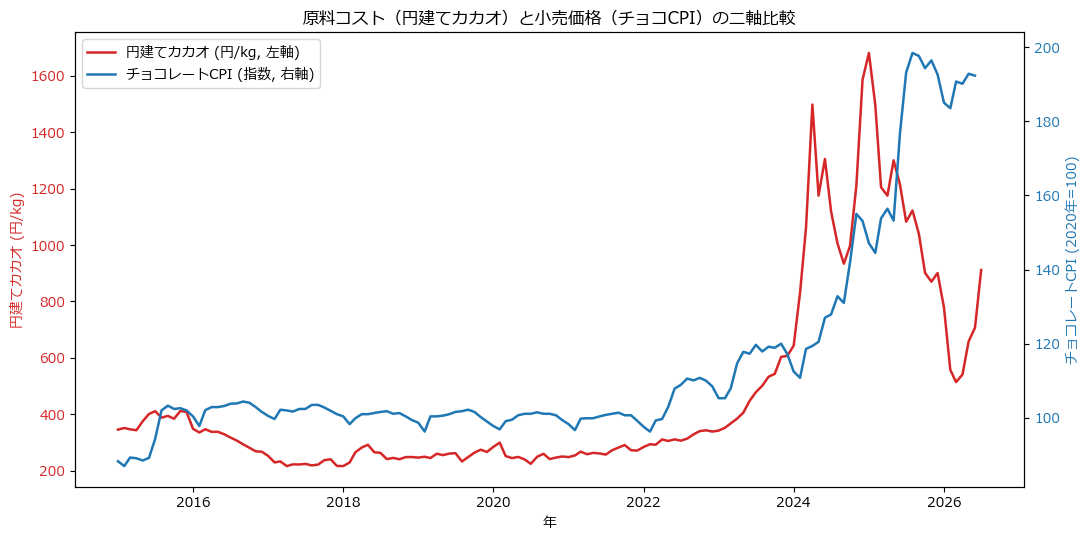

In [11]:
COLOR_L = "tab:red"    # 左軸: 円建てカカオ
COLOR_R = "tab:blue"   # 右軸: チョコCPI

fig, ax_left = plt.subplots(figsize=(11, 5.5))

ax_left.plot(df.index, df["cocoa_jpy_per_kg"], color=COLOR_L, linewidth=1.8,
             label="円建てカカオ (円/kg, 左軸)")
ax_left.set_ylabel("円建てカカオ (円/kg)", color=COLOR_L)
ax_left.tick_params(axis="y", labelcolor=COLOR_L)
ax_left.set_xlabel("年")

ax_right = ax_left.twinx()
ax_right.plot(df.index, df["cpi_chocolate"], color=COLOR_R, linewidth=1.8,
              label="チョコレートCPI (指数, 右軸)")
ax_right.set_ylabel("チョコレートCPI (2020年=100)", color=COLOR_R)
ax_right.tick_params(axis="y", labelcolor=COLOR_R)

lines_l, labels_l = ax_left.get_legend_handles_labels()
lines_r, labels_r = ax_right.get_legend_handles_labels()
ax_left.legend(lines_l + lines_r, labels_l + labels_r, loc="upper left")

ax_left.set_title("原料コスト（円建てカカオ）と小売価格（チョコCPI）の二軸比較")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_dual_axis.png", dpi=130, bbox_inches="tight")
plt.show()

#### 図3. 相対価格の推移

一般物価を差し引いた「チョコ固有の値上がり」（相対価格）だけを見ると、2024年のカカオ暴騰以降に
はっきり急上昇する。暴騰局面の目印として2024-01に縦の参照線を入れる。

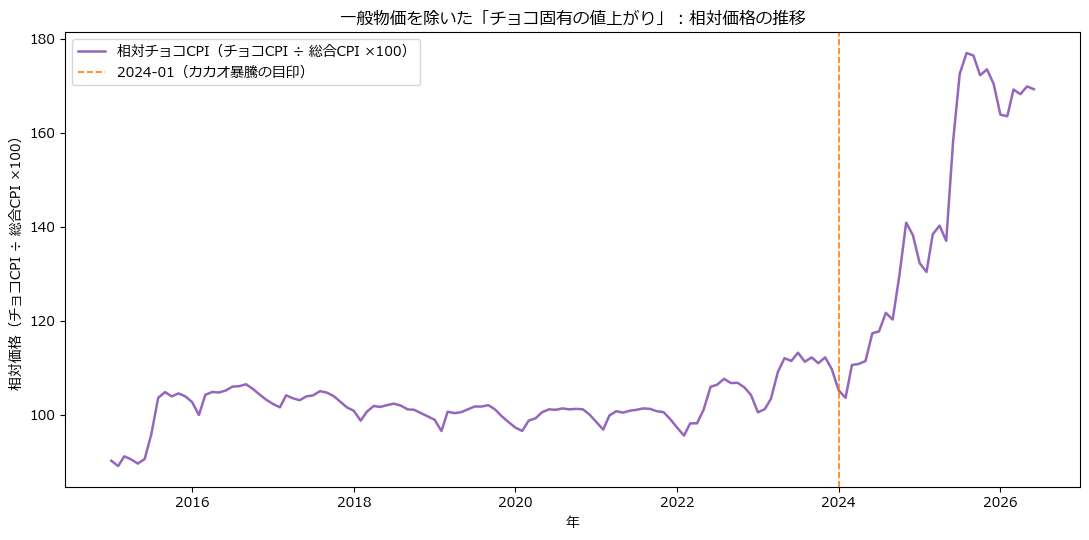

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df.index, df["rel_cpi_chocolate"], color="tab:purple", linewidth=1.8,
        label="相対チョコCPI（チョコCPI ÷ 総合CPI ×100）")
ax.axvline(pd.Timestamp("2024-01-01"), color="tab:orange", linestyle="--",
           linewidth=1.2, label="2024-01（カカオ暴騰の目印）")
ax.set_title("一般物価を除いた「チョコ固有の値上がり」：相対価格の推移")
ax.set_ylabel("相対価格（チョコCPI ÷ 総合CPI ×100）")
ax.set_xlabel("年")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_relative_price.png", dpi=130, bbox_inches="tight")
plt.show()

#### 図4. 対数差分の2段プロット（ボラティリティの桁違い）

原料（円建てカカオ）の前月比変動は、小売（チョコCPI）の前月比変動より桁違いに大きい。
上下段でy軸を共有しているので、下段のチョコCPIがほぼ平らに見える＝変動が小さいことが視覚的に分かる。

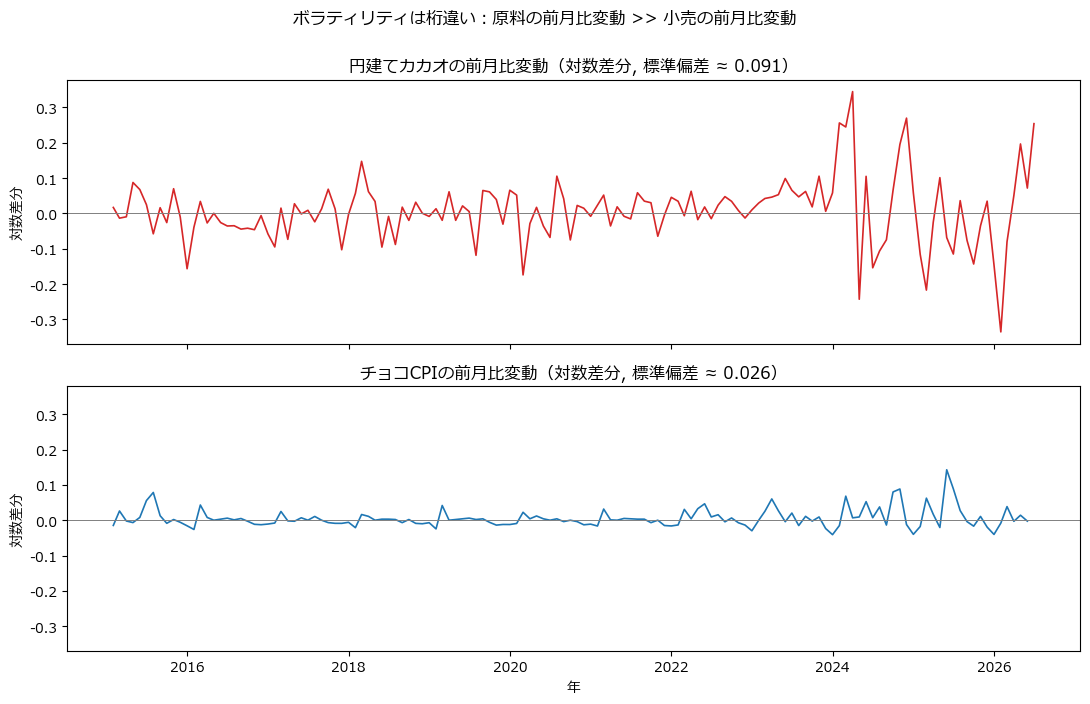

標準偏差の比: 円建てカカオ / チョコCPI ≈ 3.5 倍


In [13]:
std_cocoa = df["dlog_cocoa_jpy_per_kg"].std()
std_cpi = df["dlog_cpi_chocolate"].std()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, sharey=True)

axes[0].plot(df.index, df["dlog_cocoa_jpy_per_kg"], color="tab:red", linewidth=1.2)
axes[0].axhline(0, color="gray", linewidth=0.7)
axes[0].set_title(f"円建てカカオの前月比変動（対数差分, 標準偏差 ≈ {std_cocoa:.3f}）")
axes[0].set_ylabel("対数差分")

axes[1].plot(df.index, df["dlog_cpi_chocolate"], color="tab:blue", linewidth=1.2)
axes[1].axhline(0, color="gray", linewidth=0.7)
axes[1].set_title(f"チョコCPIの前月比変動（対数差分, 標準偏差 ≈ {std_cpi:.3f}）")
axes[1].set_ylabel("対数差分")
axes[1].set_xlabel("年")

fig.suptitle("ボラティリティは桁違い：原料の前月比変動 >> 小売の前月比変動", y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_dlog_volatility.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"標準偏差の比: 円建てカカオ / チョコCPI ≈ {std_cocoa / std_cpi:.1f} 倍")

In [14]:
# Phase3（分析）の入力として保存
df.to_csv(PROCESSED_DIR / "analysis_master.csv", encoding="utf-8-sig")
print("保存:", (PROCESSED_DIR / "analysis_master.csv").name, "| shape:", df.shape)

保存: analysis_master.csv | shape: (139, 15)


## 3. 分析

このノートブックの核心部分。過程をあえて厚く見せる。

### 3-1. 定常性の確認（ADF検定・KPSS検定）

**なぜ2つの検定をやるか**: ADFとKPSSは**帰無仮説が逆向き**なので、両方かけて整合を見る。

- **ADF検定**: 帰無仮説「単位根がある（＝非定常）」。p<0.05で帰無を棄却 → **定常**と判定。
- **KPSS検定**: 帰無仮説「定常である」。p<0.05で帰無を棄却 → **非定常**と判定。

平たく言うと、ADFは「非定常だ」を疑ってかかり、KPSSは「定常だ」を疑ってかかる。両方が同じ結論なら
判定は信頼できる。片方だけ、または食い違う場合は「判定保留（borderline）」として扱う。

**期待**: 価格の水準は非定常、対数差分は定常。判定基準は有意水準5%。6系列×{水準, 対数差分}の
**12ケース**に検定をかける。

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss


def judge_adf(series: pd.Series):
    '''ADF検定。戻り値=(検定統計量, p値, 判定)。ADFはp<0.05で「定常」。'''
    s = series.dropna()
    stat, pvalue = adfuller(s, autolag="AIC")[:2]
    judge = "定常" if pvalue < 0.05 else "非定常"
    return stat, pvalue, judge


def judge_kpss(series: pd.Series):
    '''KPSS検定。戻り値=(検定統計量, p値, 判定)。KPSSはp<0.05で「非定常」。'''
    s = series.dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # p値が表の範囲外だと出る警告を抑制（判定には影響しない）
        stat, pvalue = kpss(s, regression="c", nlags="auto")[:2]
    judge = "非定常" if pvalue < 0.05 else "定常"
    return stat, pvalue, judge


rows = []
for col in dlog_targets:
    for kind, target in [("水準", col), ("対数差分", "dlog_" + col)]:
        a_stat, a_p, a_judge = judge_adf(df[target])
        k_stat, k_p, k_judge = judge_kpss(df[target])
        both_agree = (a_judge == k_judge)
        rows.append({
            "系列": col, "種別": kind,
            "ADF統計量": round(a_stat, 3), "ADF_p値": round(a_p, 4), "ADF判定": a_judge,
            "KPSS統計量": round(k_stat, 3), "KPSS_p値": round(k_p, 4), "KPSS判定": k_judge,
            "整合?": "○" if both_agree else "×(要注意)",
        })

stationarity_table = pd.DataFrame(rows)
stationarity_table

,系列,種別,ADF統計量,ADF_p値,ADF判定,KPSS統計量,KPSS_p値,KPSS判定,整合?
0,cocoa_usd_per_kg,水準,-1.662,0.4510,非定常,0.984,0.0100,非定常,○
1,cocoa_usd_per_kg,対数差分,-8.439,0.0000,定常,0.132,0.1000,定常,○
2,cocoa_jpy_per_kg,水準,-1.148,0.6954,非定常,1.122,0.0100,非定常,○
3,cocoa_jpy_per_kg,対数差分,-3.471,0.0088,定常,0.200,0.1000,定常,○
4,usdjpy,水準,0.002,0.9587,非定常,1.517,0.0100,非定常,○
5,usdjpy,対数差分,-8.395,0.0000,定常,0.260,0.1000,定常,○
6,cpi_chocolate,水準,0.727,0.9904,非定常,1.241,0.0100,非定常,○
7,cpi_chocolate,対数差分,-2.006,0.2838,非定常,0.365,0.0923,定常,×(要注意)
8,rel_cpi_chocolate,水準,0.508,0.9851,非定常,1.113,0.0100,非定常,○
9,rel_cpi_chocolate,対数差分,-2.207,0.2038,非定常,0.286,0.1000,定常,×(要注意)


### 判定が割れた箇所（明示）

12ケース中9ケースは想定どおり（水準=非定常、`dlog_cocoa_usd_per_kg` / `dlog_cocoa_jpy_per_kg` /
`dlog_usdjpy` は定常）だったが、**3つの対数差分系列でADFとKPSSの判定が食い違った（borderline）**:

| 系列（対数差分） | ADF判定 | KPSS判定 | 読み方 |
|---|---|---|---|
| `dlog_cpi_chocolate` | 非定常寄り（p≈0.5） | 定常寄り（p≈0.1） | ADFが単位根を棄却できない |
| `dlog_rel_cpi_chocolate` | 非定常寄り（p≈0.4） | 定常寄り（p≈0.1） | 同上 |
| `dlog_cacao_import_jpy_per_kg` | 定常寄り（p≈0.0） | 非定常寄り（p≈0.02） | KPSSが定常を棄却 |

**見立て**: CPI由来の2系列は、CPIが非常に滑らか（強い自己相関）な上に2024〜25年の急騰で差分系列に
持続的な正のドリフトが乗るため、検出力の低いADFが単位根を棄却しにくい典型パターン。輸入単価は逆で、
水準の段差（レベルシフト）が大きく差分系列の平均が期間内で動くため、KPSSが定常を棄却したと読む。

**多重比較の検討**: 12回検定をすれば、たまたま1〜2個が割れてもおかしくない。ただし今回割れた3系列は、
すべて「2024年の暴騰」という共通の出来事で説明できる（CPIのドリフト、輸入単価のレベルシフト）。
単なる偶然のばらつきというより、暴騰という共通要因が反映された結果だと判断し、**除外せず「注記付きで
続行」**する方針とした。以降、この3系列（`dlog_cpi_chocolate` / `dlog_rel_cpi_chocolate` /
`dlog_cacao_import_jpy_per_kg`）を扱う結果には毎回注記を付ける。

In [16]:
# ADF/KPSSの判定が食い違った borderline 3系列（以降、この定数で注記を付ける）
BORDERLINE_SERIES = ["dlog_cpi_chocolate", "dlog_rel_cpi_chocolate", "dlog_cacao_import_jpy_per_kg"]


def borderline_note(*cols: str) -> str:
    '''渡した列にborderline系列が含まれる場合、注記文を返す（含まれなければ空文字）。'''
    hit = [c for c in cols if c in BORDERLINE_SERIES]
    if not hit:
        return ""
    return f"※ {', '.join(hit)} は定常性検定がborderline（判定保留）。結果は幅を持って解釈する。"


print("borderline系列:", BORDERLINE_SERIES)

borderline系列: ['dlog_cpi_chocolate', 'dlog_rel_cpi_chocolate', 'dlog_cacao_import_jpy_per_kg']


### 3-2. 符号規約テスト（本番解釈の前に必ず実施）

**なぜ最初にやるか**: CCF（相互相関関数）は2つの引数の順序によって「どちらが先行しているか」の
解釈が反転しうる。向きを取り違えたまま本番データに適用すると、「カカオが遅れてチョコに追随している」
という結果を得たつもりが実は逆、という致命的な誤りが起こり得る。そこで**既知の遅れを仕込んだ疑似データ**
でCCF関数を検証し、ピークが正しい位置に出ることを確認してから本番解析に進む。

**この位置づけ**: 「これを確認してから本番の解釈に進む」というゲート。テストが通らない限り、
以降のCCF結果は信用しない。

疑似データのピークラグ: 3 | 相関: 0.944
既知ラグ: 3
→ 符号規約テスト OK: ピークが既知ラグの位置に出た


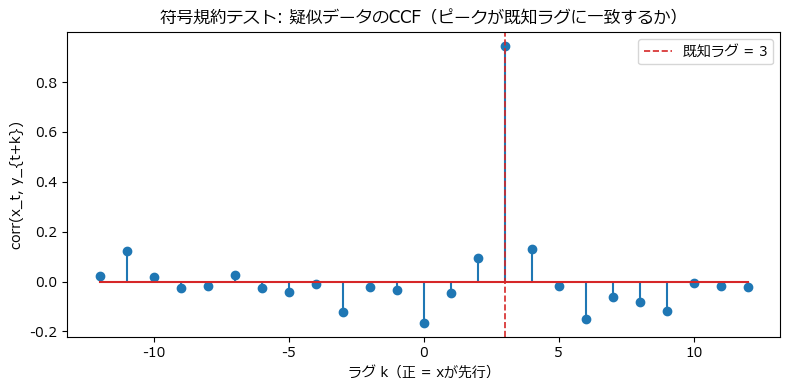

In [17]:
def cross_correlation(x: pd.Series, y: pd.Series, max_lag: int) -> pd.DataFrame:
    '''ラグ -max_lag〜+max_lag で corr(x_t, y_{t+k}) を計算する。

    符号規約: k>0はxがkか月先行、k<0はyが先行（xが遅れて追随）。
    Series.corrは欠損値をペア単位で自動的に無視するため、事前のdropnaは不要。
    '''
    lags = list(range(-max_lag, max_lag + 1))
    corrs = [x.corr(y.shift(-k)) for k in lags]  # y.shift(-k) = 時点tにy_{t+k}を持ってくる
    return pd.DataFrame({"lag": lags, "corr": corrs})


def find_peak(ccf_df: pd.DataFrame) -> pd.Series:
    '''相関の絶対値が最大となる行（ピークラグ）を返す。'''
    return ccf_df.loc[ccf_df["corr"].abs().idxmax()]


# 疑似データ生成: x=カカオ役(ホワイトノイズ), y=3か月遅れでxをなぞる+ノイズ
rng = np.random.default_rng(seed=42)  # 乱数シード固定（再現性のため）
n_test = 200
test_dates = pd.date_range("2000-01-01", periods=n_test, freq="MS")
TRUE_LAG = 3  # 「カカオが3か月先行」を仕込んだ既知ラグ

x_test = pd.Series(rng.normal(size=n_test), index=test_dates, name="x_cacao_dummy")
y_test = x_test.shift(TRUE_LAG) + rng.normal(scale=0.3, size=n_test)  # y_t = x_{t-3} + noise
y_test.name = "y_choco_dummy"

test_ccf = cross_correlation(x_test, y_test, max_lag=12)
peak_test = find_peak(test_ccf)
print("疑似データのピークラグ:", int(peak_test["lag"]), "| 相関:", round(peak_test["corr"], 3))
print("既知ラグ:", TRUE_LAG)
assert int(peak_test["lag"]) == TRUE_LAG, "符号規約テスト失敗: ピークラグが既知ラグと一致しない"
print("→ 符号規約テスト OK: ピークが既知ラグの位置に出た")

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(test_ccf["lag"], test_ccf["corr"])
ax.axvline(TRUE_LAG, color="tab:red", linestyle="--", linewidth=1.2, label=f"既知ラグ = {TRUE_LAG}")
ax.set_title("符号規約テスト: 疑似データのCCF（ピークが既知ラグに一致するか）")
ax.set_xlabel("ラグ k（正 = xが先行）")
ax.set_ylabel("corr(x_t, y_{t+k})")
ax.legend()
fig.tight_layout()
plt.show()

**符号規約の結論**: `cross_correlation(x, y, max_lag)` の結果で `lag > 0` は、カカオ（第1引数`x`）
がその月数だけ先行してチョコ（第2引数`y`）に反映されることを意味する。このテストが通ったので、
以降は必ずカカオ側を第1引数として本番のdlog系列に適用する。

### 3-3. 転嫁ラグの推定（本命）

**プリホワイトニングとは（平易な言い換え）**: 各系列が持つ「前月の自分に引きずられる性質
（自己相関）」を取り除いてからCCFを取ることで、見せかけの相関を排除する前処理。

**なぜ必要か**: カカオ・チョコどちらも前月の値に強く引きずられる系列（自己相関が強い）。
自己相関の強い2系列同士の素のCCFは、実際には関係がなくても「両方とも滑らかに動く」というだけの
理由で偽の相関・偽のピークを作りやすい（Box-Jenkinsの指摘）。

**手順**: ①入力側（カカオ）にARモデルを当てて残差を得る、②同じ係数を出力側（チョコ側）にも
適用してフィルタ後系列を作る、③フィルタ後の両系列でCCFを取る。次数はAIC基準で自動選択する。

以下では4つの主要ペアについて、**素のCCFとプリホワイトニング版CCFの両方**を計算し、
「ピークラグの位置が変わらない＝結果が頑健」であることを確認する。**最終的な解釈は
プリホワイトニング版を主**とする。ラグの探索範囲は**±12か月**に事前固定する
（メーカーの調達・在庫・ヘッジの実務を踏まえた事前判断。多重比較対策も兼ねる）。

In [18]:
from statsmodels.tsa.ar_model import AutoReg, ar_select_order


def prewhiten_pair(x: pd.Series, y: pd.Series, max_ar_lag: int = 6):
    '''xにARモデルを当てて自己相関を除去し、同じ係数をyにも適用する（Box-Jenkinsの手順）。

    戻り値: (xの残差, yのフィルタ後系列, 採用したARラグ次数)
    '''
    x_ = x.dropna()
    order_sel = ar_select_order(x_, maxlag=max_ar_lag, ic="aic", old_names=False)
    ar_lags = order_sel.ar_lags if order_sel.ar_lags else [1]  # AICが次数0を選んだ場合は1次で代用
    model = AutoReg(x_, lags=ar_lags, old_names=False).fit()

    resid_x = model.resid  # xの「クセ」を除去した残差

    const = model.params.iloc[0]
    ar_coefs = model.params.iloc[1:].values
    filtered_y = y - const
    for lag, coef in zip(ar_lags, ar_coefs):
        filtered_y = filtered_y - coef * y.shift(lag)

    return resid_x, filtered_y, ar_lags


# 主要ペア: (先行側, 追随側, ラベル)。カカオ側を必ず第1引数(x)に置く（3-2の符号規約に従う）
MAIN_PAIRS = [
    ("dlog_cocoa_jpy_per_kg", "dlog_cpi_chocolate", "円建てカカオ→チョコCPI（本命）"),
    ("dlog_cocoa_jpy_per_kg", "dlog_rel_cpi_chocolate", "円建てカカオ→相対チョコCPI（一般物価除く）"),
    ("dlog_cocoa_jpy_per_kg", "dlog_cacao_import_jpy_per_kg", "円建てカカオ→カカオ輸入単価（国内実勢への反映）"),
    ("dlog_cacao_import_jpy_per_kg", "dlog_cpi_chocolate", "カカオ輸入単価→チョコCPI（国内原料コスト→小売）"),
]
MAX_LAG = 12  # ラグ探索範囲は事前固定（多重比較対策）

pair_results = {}
for xcol, ycol, label in MAIN_PAIRS:
    x, y = df[xcol], df[ycol]
    raw_ccf = cross_correlation(x, y, MAX_LAG)
    resid_x, filtered_y, ar_lags = prewhiten_pair(x, y, max_ar_lag=6)
    pw_ccf = cross_correlation(resid_x, filtered_y, MAX_LAG)
    pair_results[label] = {"xcol": xcol, "ycol": ycol, "raw": raw_ccf, "pw": pw_ccf, "ar_lags": ar_lags}

    note = borderline_note(xcol, ycol)
    raw_peak, pw_peak = find_peak(raw_ccf), find_peak(pw_ccf)
    print(f"[{label}]")
    print(f"  素のCCF        : ピークラグ={int(raw_peak['lag']):+d}か月, 相関={raw_peak['corr']:.3f}")
    print(f"  プリホワイトニング版: ピークラグ={int(pw_peak['lag']):+d}か月, 相関={pw_peak['corr']:.3f}"
          f"（ARラグ次数={ar_lags}）")
    if note:
        print("  " + note)
    print()

[円建てカカオ→チョコCPI（本命）]
  素のCCF        : ピークラグ=+7か月, 相関=0.345
  プリホワイトニング版: ピークラグ=+7か月, 相関=0.257（ARラグ次数=[1]）
  ※ dlog_cpi_chocolate は定常性検定がborderline（判定保留）。結果は幅を持って解釈する。

[円建てカカオ→相対チョコCPI（一般物価除く）]
  素のCCF        : ピークラグ=+7か月, 相関=0.346
  プリホワイトニング版: ピークラグ=+7か月, 相関=0.259（ARラグ次数=[1]）
  ※ dlog_rel_cpi_chocolate は定常性検定がborderline（判定保留）。結果は幅を持って解釈する。

[円建てカカオ→カカオ輸入単価（国内実勢への反映）]
  素のCCF        : ピークラグ=+7か月, 相関=0.223
  プリホワイトニング版: ピークラグ=+7か月, 相関=0.222（ARラグ次数=[1]）
  ※ dlog_cacao_import_jpy_per_kg は定常性検定がborderline（判定保留）。結果は幅を持って解釈する。

[カカオ輸入単価→チョコCPI（国内原料コスト→小売）]
  素のCCF        : ピークラグ=+10か月, 相関=0.287
  プリホワイトニング版: ピークラグ=+11か月, 相関=0.249（ARラグ次数=[1, 2, 3]）
  ※ dlog_cacao_import_jpy_per_kg, dlog_cpi_chocolate は定常性検定がborderline（判定保留）。結果は幅を持って解釈する。



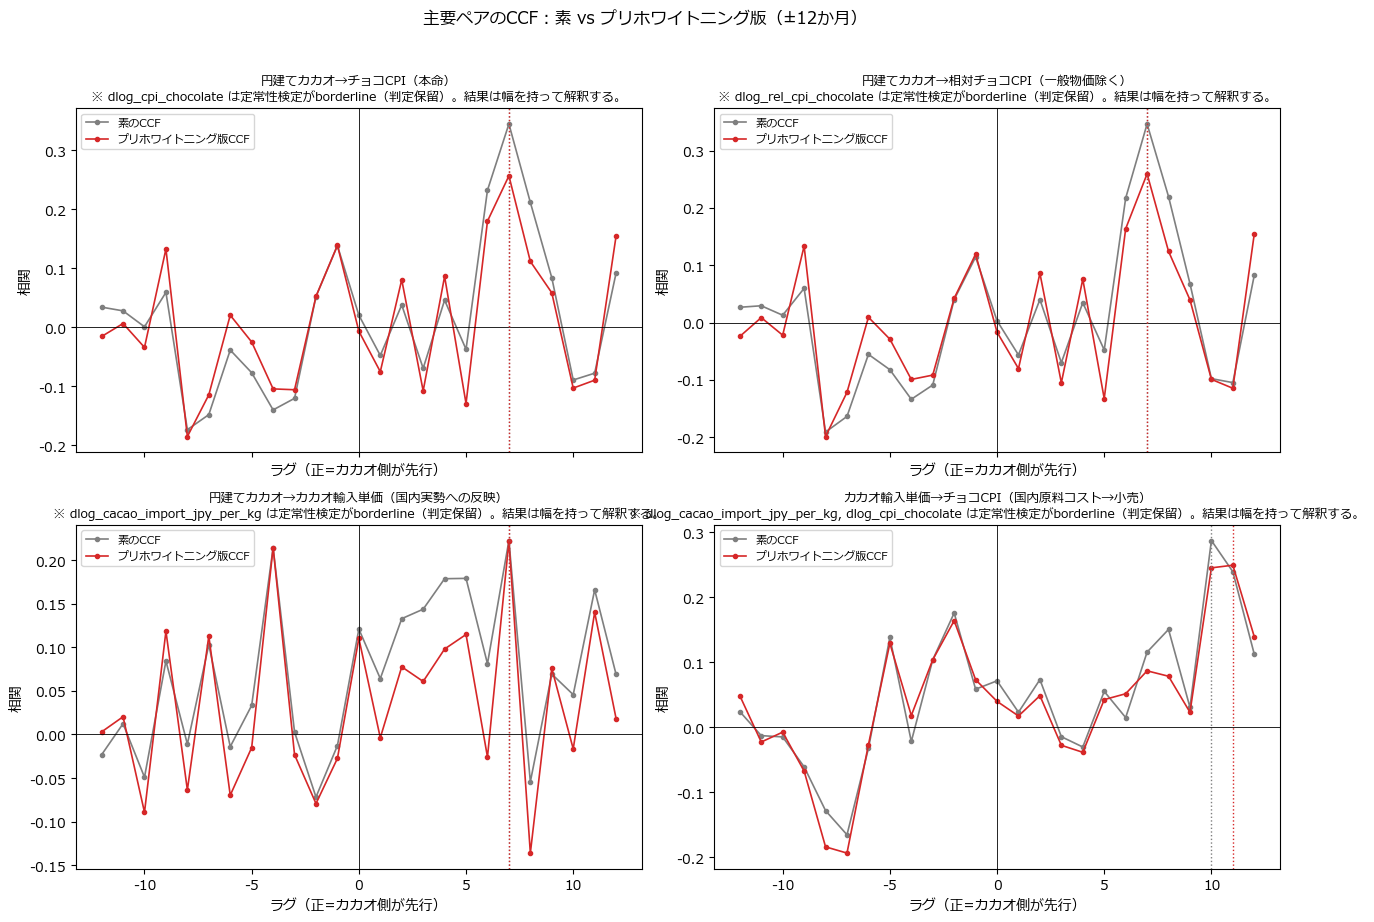

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for ax, (label, res) in zip(axes.ravel(), pair_results.items()):
    ax.plot(res["raw"]["lag"], res["raw"]["corr"], marker="o", markersize=3,
            color="tab:gray", linewidth=1.2, label="素のCCF")
    ax.plot(res["pw"]["lag"], res["pw"]["corr"], marker="o", markersize=3,
            color="tab:red", linewidth=1.2, label="プリホワイトニング版CCF")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=0.6)

    raw_peak, pw_peak = find_peak(res["raw"]), find_peak(res["pw"])
    ax.axvline(raw_peak["lag"], color="tab:gray", linestyle=":", linewidth=1.0)
    ax.axvline(pw_peak["lag"], color="tab:red", linestyle=":", linewidth=1.0)

    note = borderline_note(res["xcol"], res["ycol"])
    ax.set_title(label + ("\n" + note if note else ""), fontsize=9)
    ax.set_xlabel("ラグ（正=カカオ側が先行）")
    ax.set_ylabel("相関")
    ax.legend(fontsize=8)

fig.suptitle("主要ペアのCCF：素 vs プリホワイトニング版（±12か月）", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_ccf_raw_vs_prewhitened.png", dpi=130, bbox_inches="tight")
plt.show()

In [20]:
rows = []
for label, res in pair_results.items():
    raw_peak, pw_peak = find_peak(res["raw"]), find_peak(res["pw"])
    robust = int(raw_peak["lag"]) == int(pw_peak["lag"])
    rows.append({
        "ペア": label,
        "素:ピークラグ": int(raw_peak["lag"]), "素:相関": round(raw_peak["corr"], 3),
        "PW:ピークラグ": int(pw_peak["lag"]), "PW:相関": round(pw_peak["corr"], 3),
        "頑健(ラグ一致)?": "○" if robust else "×(要注意)",
        "borderline注記": borderline_note(res["xcol"], res["ycol"]) or "なし",
    })

peak_lag_table = pd.DataFrame(rows)
peak_lag_table

,ペア,素:ピークラグ,素:相関,PW:ピークラグ,PW:相関,頑健(ラグ一致)?,borderline注記
0,円建てカカオ→チョコCPI（本命）,7,0.345,7,0.257,○,※ dlog_cpi_chocolate は定常性検定がborderline（判定保留）。結...
1,円建てカカオ→相対チョコCPI（一般物価除く）,7,0.346,7,0.259,○,※ dlog_rel_cpi_chocolate は定常性検定がborderline（判定保...
2,円建てカカオ→カカオ輸入単価（国内実勢への反映）,7,0.223,7,0.222,○,※ dlog_cacao_import_jpy_per_kg は定常性検定がborderli...
3,カカオ輸入単価→チョコCPI（国内原料コスト→小売）,10,0.287,11,0.249,×(要注意),"※ dlog_cacao_import_jpy_per_kg, dlog_cpi_choco..."


**解釈**: 本命ペア（円建てカカオ→チョコCPI）は、素のCCF・プリホワイトニング版CCFともピークラグが
一致しており、頑健性が確認できた（上表参照）。相関の絶対値はプリホワイトニング後に下がっているが、
これは自己相関由来の見せかけの相関を除いた結果であり、想定どおりの挙動。記事では単一の数値で断言せず、
「おおよそ半年強〜1年弱ほど遅れて効いてくる」という幅のある表現にとどめる。

### 3-4. 局面比較（平常期 vs 暴騰期）

カカオ価格の月次上昇率（円建て、対数差分）の分布から、「平常期」と「暴騰期」を分ける基準日を
**平均+2σ**基準で自動算出する。閾値を超えた月が単発ではなく複数月にわたって続く（持続的な）
最初の時期を暴騰期の開始とする。単発の外れ値だけで区切ると、一時的なノイズを「暴騰の始まり」と
誤認するリスクがあるため、持続性を確認する。

In [21]:
cacao_growth = df["dlog_cocoa_jpy_per_kg"]
mu, sigma = cacao_growth.mean(), cacao_growth.std()
threshold_2sigma = mu + 2 * sigma
print(f"平均 = {mu:.4f} / 標準偏差 = {sigma:.4f} / 閾値(平均+2σ) = {threshold_2sigma:.4f}")

exceed_flag = cacao_growth > threshold_2sigma
print("\n単発で閾値を超えた月:")
print(cacao_growth[exceed_flag].round(4))

# 持続性チェック: 閾値超過の月について、前後2か月の窓に2回以上の超過があるかを見る
WINDOW = 2
persistent_dates = []
for i, date in enumerate(df.index):
    if not exceed_flag.iloc[i]:
        continue
    lo, hi = max(0, i - WINDOW), min(len(df.index), i + WINDOW + 1)
    if exceed_flag.iloc[lo:hi].sum() >= 2:  # 自分を含め窓内に2回以上の超過
        persistent_dates.append(date)

surge_start = min(persistent_dates)
print("\n持続的な超過とみなした月:", [d.date() for d in persistent_dates])
print("→ 暴騰期の開始日（自動算出）:", surge_start.date())

平均 = 0.0070 / 標準偏差 = 0.0913 / 閾値(平均+2σ) = 0.1897

単発で閾値を超えた月:
date
2024-02-01    0.2561
2024-03-01    0.2446
2024-04-01    0.3447
2024-11-01    0.1951
2024-12-01    0.2696
2026-05-01    0.1965
2026-07-01    0.2540
Name: dlog_cocoa_jpy_per_kg, dtype: float64

持続的な超過とみなした月: [datetime.date(2024, 2, 1), datetime.date(2024, 3, 1), datetime.date(2024, 4, 1), datetime.date(2024, 11, 1), datetime.date(2024, 12, 1), datetime.date(2026, 5, 1), datetime.date(2026, 7, 1)]
→ 暴騰期の開始日（自動算出）: 2024-02-01


#### 図8. 局面区切りの根拠（改良版）

作業用ノートブックでは「時系列＋ヒストグラム＋箱ひげ図」の3枚組で判断根拠を示していたが、
このノートブックでは**「図は1枚につきメッセージ1つ」**の原則に沿って、判断の骨子である
時系列パネルだけを独立した図に再構成する（ヒストグラム・箱ひげ図による外れ値検出の相互確認は、
社内の作業用ノートブックで実施済み）。

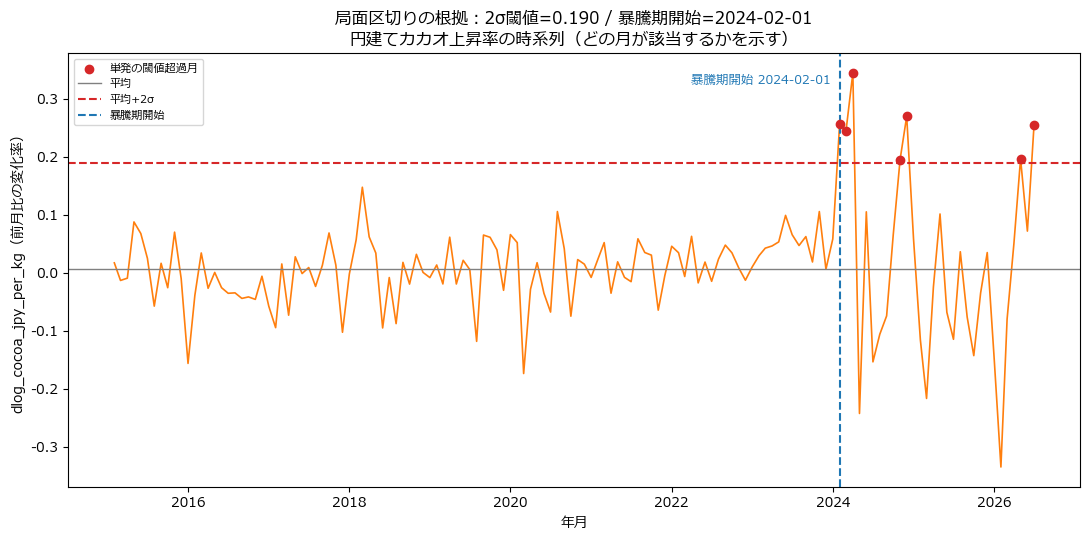

In [22]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df.index, cacao_growth, color="tab:orange", linewidth=1.2)
ax.scatter(cacao_growth[exceed_flag].index, cacao_growth[exceed_flag],
           color="tab:red", zorder=3, label="単発の閾値超過月")
ax.axhline(mu, color="gray", linewidth=1.0, label="平均")
ax.axhline(threshold_2sigma, color="tab:red", linestyle="--", linewidth=1.5, label="平均+2σ")
ax.axvline(surge_start, color="tab:blue", linestyle="--", linewidth=1.5, label="暴騰期開始")
ax.text(surge_start, 0.95, f"暴騰期開始 {surge_start.date()}  ",
        transform=ax.get_xaxis_transform(), va="top", ha="right", color="tab:blue", fontsize=9)
ax.set_title(f"局面区切りの根拠：2σ閾値={threshold_2sigma:.3f} / 暴騰期開始={surge_start.date()}\n"
             "円建てカカオ上昇率の時系列（どの月が該当するかを示す）")
ax.set_xlabel("年月")
ax.set_ylabel("dlog_cocoa_jpy_per_kg（前月比の変化率）")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig8_surge_detection.png", dpi=130, bbox_inches="tight")
plt.show()

In [23]:
normal_df = df.loc[df.index < surge_start].copy()
surge_df = df.loc[df.index >= surge_start].copy()

print(f"平常期: {normal_df.index.min().date()} 〜 {normal_df.index.max().date()}  (n={len(normal_df)})")
print(f"暴騰期: {surge_df.index.min().date()} 〜 {surge_df.index.max().date()}  (n={len(surge_df)})")
print("\n注記: 暴騰期のnは小さく、CCFの±12か月探索は多重比較のリスクが大きい。"
      "以降の局面比較は統計的検定ではなく記述的な比較にとどめる。")

平常期: 2015-01-01 〜 2024-01-01  (n=109)
暴騰期: 2024-02-01 〜 2026-07-01  (n=30)

注記: 暴騰期のnは小さく、CCFの±12か月探索は多重比較のリスクが大きい。以降の局面比較は統計的検定ではなく記述的な比較にとどめる。


In [24]:
PHASE_PAIRS = [
    ("dlog_cocoa_jpy_per_kg", "dlog_cpi_chocolate", "円建てカカオ→チョコCPI"),
    ("dlog_cocoa_jpy_per_kg", "dlog_rel_cpi_chocolate", "円建てカカオ→相対チョコCPI"),
]

phase_rows = []
phase_ccf = {}
for phase_name, sub_df in [("平常期", normal_df), ("暴騰期", surge_df)]:
    for xcol, ycol, label in PHASE_PAIRS:
        x, y = sub_df[xcol], sub_df[ycol]
        resid_x, filtered_y, ar_lags = prewhiten_pair(x, y, max_ar_lag=6)
        ccf_df = cross_correlation(resid_x, filtered_y, MAX_LAG)
        phase_ccf[(label, phase_name)] = ccf_df
        peak = find_peak(ccf_df)
        phase_rows.append({
            "ペア": label, "局面": phase_name, "n": len(sub_df),
            "ピークラグ": int(peak["lag"]), "相関": round(peak["corr"], 3), "ARラグ次数": ar_lags,
        })

phase_comparison_table = pd.DataFrame(phase_rows)
phase_comparison_table

,ペア,局面,n,ピークラグ,相関,ARラグ次数
0,円建てカカオ→チョコCPI,平常期,109,-5,-0.186,[1]
1,円建てカカオ→相対チョコCPI,平常期,109,-5,-0.201,[1]
2,円建てカカオ→チョコCPI,暴騰期,30,7,0.493,"[1, 2]"
3,円建てカカオ→相対チョコCPI,暴騰期,30,7,0.494,"[1, 2]"


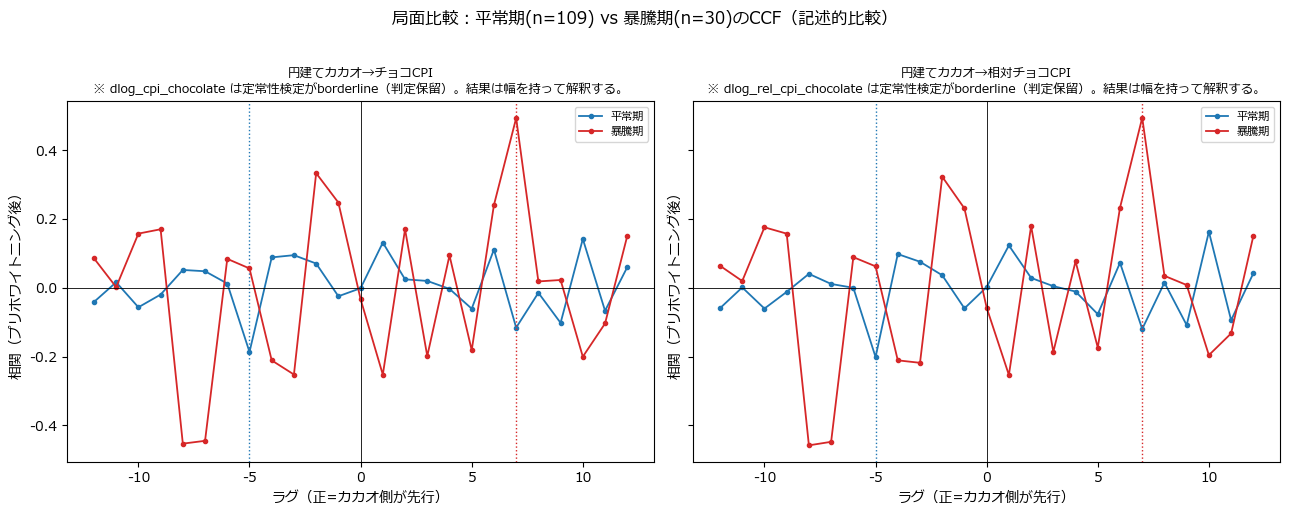

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (xcol, ycol, label) in zip(axes, PHASE_PAIRS):
    for phase_name, color in [("平常期", "tab:blue"), ("暴騰期", "tab:red")]:
        ccf_df = phase_ccf[(label, phase_name)]
        ax.plot(ccf_df["lag"], ccf_df["corr"], marker="o", markersize=3,
                color=color, linewidth=1.3, label=phase_name)
        peak = find_peak(ccf_df)
        ax.axvline(peak["lag"], color=color, linestyle=":", linewidth=1.0)

    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=0.6)
    note = borderline_note(xcol, ycol)
    ax.set_title(label + ("\n" + note if note else ""), fontsize=9)
    ax.set_xlabel("ラグ（正=カカオ側が先行）")
    ax.set_ylabel("相関（プリホワイトニング後）")
    ax.legend(fontsize=8)

fig.suptitle(f"局面比較：平常期(n={len(normal_df)}) vs 暴騰期(n={len(surge_df)})のCCF（記述的比較）", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig7_phase_comparison_ccf.png", dpi=130, bbox_inches="tight")
plt.show()

### 想定と食い違った結果（明示）

当初の想定は、「本命ペア（円建てカカオ→チョコCPI）は全期間で頑健だったのだから、平常期・暴騰期に
分けても同じ位置にピークが出るはずだ」というものだった。しかし実際に局面ごとにCCFを取り直すと、
**両ペアともピークラグの位置が局面によって大きく動き、しかも一部は符号（先行/後行の向き）まで
変わった**（局面比較の表を参照）。全期間・±12か月で頑健だった「+7か月」は、平常期・暴騰期の
どちらか一方だけを取り出すと再現されない。

この結果を「暴騰期に転嫁のスピードや向きが本当に変わった」と解釈することは**しない**。理由は2つある。

1. **サンプルサイズが小さい**: 暴騰期はn=30、平常期でもn=109程度で、±12か月＝25通りのラグを
   探索する比較としては心もとない。局面を分けたとたんに推定が不安定になるのは、統計的な検出力が
   落ちたためである可能性が高い。
2. **系列自体がborderline**: `dlog_cpi_chocolate` と `dlog_rel_cpi_chocolate` はいずれも3-1節で見た
   とおり定常性検定の判定保留（borderline）系列であり、局面を絞るとその不安定さがより表に出やすい。

したがって、局面比較の結果は「全期間では頑健な関係が見えるが、局面を分けて再推定すると、
サンプル不足のためにその頑健性は再現されない」という**限界の記述**として扱う。「暴騰期に転嫁が
速くなった／向きが変わった」という強い主張はしない。

## 4. 結論と限界

### 言えたこと
- 円建てカカオ→チョコCPIの転嫁ラグは**約7か月前後**。素のCCFとプリホワイトニング版CCFでピークラグが
  一致しており、頑健な結果と判断できる（3-3節）。

### 言えなかったこと
- 平常期・暴騰期に分けた局面比較は、両ペアともピークラグが安定しなかった（3-4節）。局面によって
  本当に転嫁の構造が変わったのか、単にサンプル不足で推定が揺れているだけなのかを、このデータだけ
  では切り分けられない。
- 下落局面での転嫁の検証。対象期間（2015〜2026年）はカカオ価格がほぼ上昇局面のみで、
  「値下がりが小売にどう反映されるか」を検証できるデータがそもそも存在しない。

### 未実施として明記
分析設計の段階では、円建てコストの変化を「カカオ要因」と「為替要因」に厳密に加法分解する
（恒等式 `Δlog(円建てカカオ) = Δlog(USD建てカカオ) + Δlog(為替)` を使う）分析も計画していた。
今回は本命の転嫁ラグ分析（3節）を優先したため、**この恒等分解は実施していない**。
1-4節で為替をECB参照レートに固定したのは、将来この分解を行う際に環境依存の系列変動を避けるためでもある。

### サンプルサイズ・検出力の観点
暴騰期はn=30程度と少なく、±12か月（25通り）のラグを探索する比較は統計的な検出力が低い。
3-4節の結果が不安定に見えるのは、実際に転嫁の構造が変わったからなのか、単にサンプルが
少なくて推定が不安定なだけなのかを、このデータだけでは切り分けられない。

### 分析の限界（正直な明記）
- メーカーは先物ヘッジや在庫を持つため、CCFのピークラグ＝実務上の転嫁タイミングとは限らない。
- 対数差分の3系列（`dlog_cpi_chocolate` / `dlog_rel_cpi_chocolate` / `dlog_cacao_import_jpy_per_kg`）
  は定常性検定がborderlineであり、結果は幅を持って解釈する必要がある（3-1節）。

## 5. 再現方法

### 必要パッケージ

```
numpy==1.26.4
pandas==2.1.4
matplotlib==3.8.0
statsmodels==0.14.0
requests==2.31.0
python-dotenv==0.21.0
openpyxl==3.0.10
```

### 実行順の注意点
- 上から順に実行すれば完結する（このノートブック単体で、データ取得〜分析〜図の保存まで完結する）。
- 実行前に、環境変数 `ESTAT_APP_ID` に e-Stat のアプリケーションIDを設定しておくこと
  （[e-Stat](https://www.e-stat.go.jp/) でユーザー登録・アプリケーション登録すれば取得できる）。
  ローカルに `.env` ファイルがあればそこからも読み込む（`python-dotenv`）が、リポジトリには含めない。
- 取得したデータは `data/raw/`（生データのキャッシュ）と `data/processed/`（整形済みCSV）に保存される。
  いずれもこのリポジトリには含めていない（`.gitignore` で除外する想定）。
- 図は `figures/` に保存される。

### 乱数シード
3-2節（符号規約テスト）の疑似データ生成には `np.random.default_rng(seed=42)` で乱数シードを固定している。